In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap, Normalize
import os, re
import codecs, warnings
from scipy import optimize, constants as const
from scipy.optimize import curve_fit
import uncertainties
from uncertainties import ufloat, unumpy

colors = ["red","darkorange","gold","lawngreen","lightseagreen","blueviolet","indigo"][::-1]
cmap = LinearSegmentedColormap.from_list("mycmap",colors)
num = 36
gradient1 = plt.cm.Oranges(np.linspace(0, 1, num))[::-1]
gradient2 = plt.cm.Purples(np.linspace(0, 1, num))[::-1]
gradient3 = plt.cm.Greens(np.linspace(0, 1, num))[::-1]
gradient = cmap(np.linspace(0, 1, num))[::-1] 


In [2]:
q = 23e6#m-1
a = 0.25e-6#m
π = np.pi

# def f2msd(f,q=23,d=3):
#     return -2*d/q**2 * unumpy.log(f)
def f2msd(f,q=23e6,d=3):
    return -2*d/q**2 * np.log(f)

def sort_files(filename):
    """sort files of cooling by measurement order"""
    files = np.empty((180,4))
    for i in range(1,181):
        file = filename.format(i)
        files[i-1,0] = i
        with open(file) as f:
            for line in f:
                if ".nsz" in line:
                    match = re.search(r'_(\d+)\.nsz', line)
                    files[i-1,1] = int(match.group(1))
                if "Temperature of the Holder" in line:
                    T = float(line.split(",")[1])
                    files[i-1,2] = T
                if "Count Rate" in line:
                    c = float(line.split(",")[1])
                    files[i-1,3] = c
    return files[np.argsort(files[:, 1])]

def get_g1(file):
    """get autocorrelation function from file"""
    with open(file) as f:
        for line in f:
            if "Correlation g1(T)" in line:
                data = np.loadtxt(f, delimiter=",", skiprows=0)
    return data[:,1]

def get_cooling(files):
    """get all data of one cooling, 
    returns a matrix (36x5x36) corresponding to (T, repeat, g1)"""
    cool = np.zeros((36,5,36))
    for i,n in enumerate(files[::,0]):
        file = name.format(int(n))
        data = get_g1(file)
        cool[i//5, i%5, :] = data
    return cool

In [3]:
def mmGp(ω, k, η):
    '''Elastic modulus of the Maxwell Model'''
    τ = η/k
    return k * (
        τ**2 * ω**2
    )/(
        1 + τ**2 * ω**2
    )
def mmGpp(ω, k, η):
    '''Viscous modulus of the Maxwell Model'''
    τ = η/k
    return k * (
        τ * ω
    )/(
        1 + τ**2 * ω**2
    )
def mmtandelta(ω, k, η):
    '''Loss tangent of the Maxwell Model'''
    τ = η/k
    return 1/(τ * ω)

def mmJ(t, k, η):
    '''Creep compliance of the Maxwell Model'''
    return 1/k + t/η

def jsGp(ω, k, η, ηs):
    '''Elastic modulus of the Johnson-Segalman model'''
    return mmGp(ω, k, η)
    
def jsGpp(ω, k, η, ηs):
    '''Viscous modulus of the Johnson-Segalman model'''
    return mmGpp(ω, k, η) + ηs*ω

def jstandelta(ω, k, η, ηs):
    '''Loss tangent of the Johnson-Segalman model'''
    return mmtandelta(ω, k, η) + ηs*ω / mmGp(ω, k, η)

def jsJ(t, k, η, ηs):
    '''Creep compliance of the Johnson-Segalman model'''
    return t/(η+ηs) + 1/k * (η/(η+ηs))**2 * (1 - np.exp(-k*(1/η + 1/ηs)*t))


In [4]:
Dt = np.array([1.00000e+00, 1.40000e+00, 1.90000e+00, 2.60000e+00, 3.60000e+00,
       5.00000e+00, 6.90000e+00, 9.50000e+00, 1.31000e+01, 1.81000e+01,
       2.50000e+01, 3.45000e+01, 4.76000e+01, 6.57000e+01, 9.07000e+01,
       1.25200e+02, 1.72800e+02, 2.38500e+02, 3.29200e+02, 4.54400e+02,
       6.27200e+02, 8.65700e+02, 1.19490e+03, 1.64930e+03, 2.27650e+03,
       3.14220e+03, 4.33710e+03, 5.98640e+03, 8.26290e+03, 1.14051e+04,
       1.57422e+04, 2.17286e+04, 2.99915e+04, 4.13966e+04, 5.71388e+04,
       7.88674e+04])*1e-6  #s

In [5]:
os.chdir(r"C:\Users\ajiye\Documents\DLS\Y6")
files = np.empty((180,4))

name = "cooling_1/Y16SE6-1mM-NP500nm-0.1pct-properprotocol2_cool1_{:03d}.csv"
files = sort_files(name)
cool1 = get_cooling(files)
T1 = np.reshape(files[:,2],(36,5))
c1 = np.reshape(files[:,3],(36,5))

name = "cooling_2/Y16SE6-1mM-NP500nm-0.1pct-properprotocol2_cool2_{:03d}.csv"
files = sort_files(name)
cool2 = get_cooling(files)
T2 = np.reshape(files[:,2],(36,5))
c2 = np.reshape(files[:,3],(36,5))

name = "cooling_3/Y16SE6-1mM-NP500nm-0.1pct-properprotocol2_cool3_{:03d}.csv"
files = sort_files(name)
cool3 = get_cooling(files)
T3 = np.reshape(files[:,2],(36,5))
c3 = np.reshape(files[:,3],(36,5))

name = "cooling_4/Y16SE6-1mM-NP500nm-0.1pct-properprotocol2_cool4_{:03d}.csv"
files = sort_files(name)
cool4 = get_cooling(files)
T4 = np.reshape(files[:,2],(36,5))
c4 = np.reshape(files[:,3],(36,5))

name = "cooling_5/Y16SE6-1mM-NP500nm-0.1pct-properprotocol2_cool5_{:03d}.csv"
files = sort_files(name)
cool5 = get_cooling(files)
T5 = np.reshape(files[:,2],(36,5))
c5 = np.reshape(files[:,3],(36,5))


analyse preliminaire

Text(0.5, 1.0, '60 C')

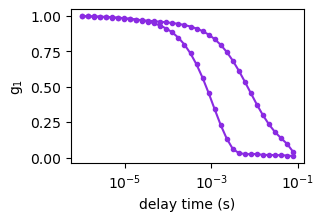

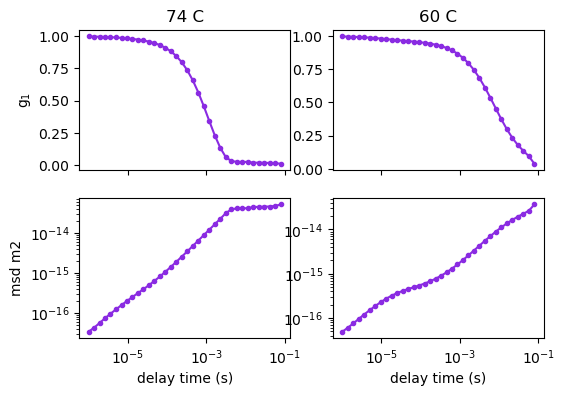

In [6]:
colors = ["red","orange","forestgreen","lightseagreen","blueviolet"]
fig1, ax1 = plt.subplots(1, 1, figsize=(3,2))
fig2, ax2 = plt.subplots(2, 2, figsize=(6,4), sharex=True)
coolings = [cool1, cool2, cool3, cool4, cool5]
counts = [c1, c2, c3, c4, c5]
T_high, T_low = 10, 19
s_high, s_low = 0, 0
sum_count_high, sum_count_low = 0, 0
for i, cooling in enumerate(coolings):
    count = counts[i] 
    sum_count_high += np.sum(count[T_high,:])
    sum_count_low += np.sum(count[T_low,:])
    for j in range(5):
        g2 = cooling[T_high,j,:]**2 + 1
        s_high += (g2 * count[T_high,j])
        g2 = cooling[T_low,j,:]**2 + 1
        s_low += (g2 * count[T_low,j])
g1_high = np.sqrt(s_high/sum_count_high - 1)
g1_low = np.sqrt(s_low/sum_count_low - 1)

msd1_high = f2msd(g1_high, q)
msd1_low = f2msd(g1_low, q)

ax1.plot(Dt, g1_high, color=colors[i], marker='.', label=f'cooling {i+1}')
ax1.plot(Dt, g1_low, color=colors[i], marker='.')

ax2[0,0].plot(Dt, g1_high, color=colors[i], marker='.', label=f'cooling {i+1}')
ax2[0,1].plot(Dt, g1_low, color=colors[i], marker='.')
ax2[1,0].plot(Dt, msd1_high, color=colors[i], marker='.', label=f'cooling {i+1}')
ax2[1,1].plot(Dt, msd1_low, color=colors[i], marker='.')
    
        
    # f_high = unumpy.uarray(np.mean(cooling[10,:,:], axis=0), np.std(cooling[10,:,:], axis=0))
    # f_low = unumpy.uarray(np.mean(cooling[19,:,:], axis=0), np.std(cooling[19,:,:], axis=0))
    # msd_high = f2msd(f_high, q)
    # msd_low = f2msd(f_low, q)
    
    # ax1.errorbar(Dt, unumpy.nominal_values(f_high), yerr=unumpy.std_devs(f_high), color=colors[i], marker='.', label=f'cooling {i+1}')
    # ax1.errorbar(Dt, unumpy.nominal_values(f_low), yerr=unumpy.std_devs(f_low), color=colors[i], marker='.')
    
    # ax2[0,0].errorbar(Dt, unumpy.nominal_values(f_high), yerr=unumpy.std_devs(f_high), color=colors[i], marker='.', label=f'cooling {i+1}')
    # ax2[0,1].errorbar(Dt, unumpy.nominal_values(f_low), yerr=unumpy.std_devs(f_low), color=colors[i], marker='.')
    # ax2[1,0].errorbar(Dt, unumpy.nominal_values(msd_high), yerr=unumpy.std_devs(msd_high), color=colors[i], marker='.', label=f'cooling {i+1}')
    # ax2[1,1].errorbar(Dt, unumpy.nominal_values(msd_low), yerr=unumpy.std_devs(msd_low), color=colors[i], marker='.')
    
ax1.set_xscale('log')
ax1.set_xlabel('delay time (s)')
ax1.set_ylabel('g$_1$')
# ax1.legend()

ax2[1,0].set_xscale('log')
ax2[1,1].set_xscale('log')
ax2[1,0].set_yscale('log')
ax2[1,1].set_yscale('log')
ax2[1,0].set_xlabel('delay time (s)')
ax2[1,1].set_xlabel('delay time (s)')
ax2[0,0].set_ylabel('g$_1$')
ax2[1,0].set_ylabel('msd m2')
ax2[0,0].set_title('74 C')
ax2[0,1].set_title('60 C')


Water viscosity

In [7]:
from scipy.interpolate import CubicSpline
water = np.loadtxt(f'C:/Users/ajiye/Documents/DLS/water.tsv', skiprows=1)
eta_w = CubicSpline(water[:,0], water[:,1]*1e-3)

C:\Users\ajiye\AppData\Local\Temp\ipykernel_19924\497340079.py:8: RuntimeWarning: divide by zero encountered in log
  return -2*d/q**2 * np.log(f)


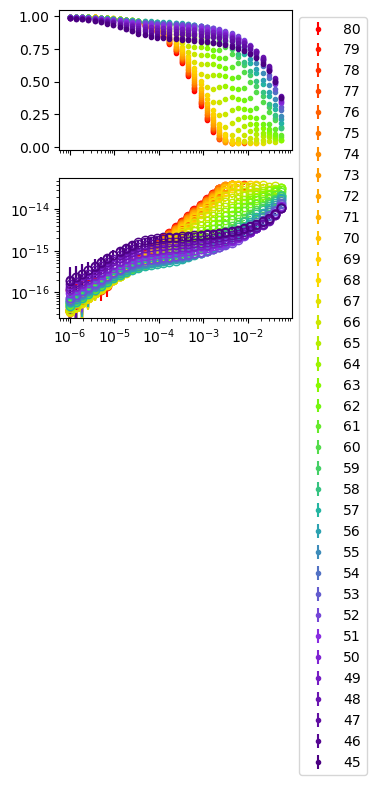

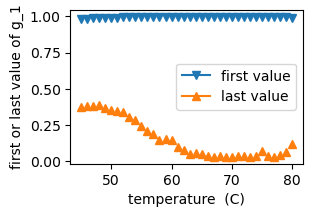

In [8]:
colors = ["red","darkorange","gold","lawngreen","lightseagreen","blueviolet","indigo"][::-1]
cmap = LinearSegmentedColormap.from_list("mycmap",colors)
num = 36
gradient = cmap(np.linspace(0, 1, num))[::-1] 

fig3, ax3 = plt.subplots(2, 1, figsize=(3,4), sharex=True)
fig4, ax4 = plt.subplots(1, 1, figsize=(3,2))

coolings = [cool1, cool2, cool3, cool4, cool5]
counts = [c1, c2, c3, c4, c5]
labels = list(range(80,44,-1))

G1 = np.empty((36,36))
MSD = np.empty((36,36))
err_minus = np.empty((36,36))
err_plus = np.empty((36,36))

for T in range(0,36,1):
    # print(labels[T])
    # moyennage g1 par temperature (num de cooling et num mesure confondus)
    s = 0
    sum_count = 0
    for i, cooling in enumerate(coolings):
        count = counts[i] 
        sum_count += np.sum(count[T,:])
        for j in range(5):
            g2 = cooling[T,j,:]**2 + 1
            s += (g2 * count[T,j])
    g1 = np.sqrt(s/sum_count - 1)
    G1[T,:] = g1
    err_f = 1-g1[0]
    select = np.where(g1>10*err_f)[0]
    ax3[0].errorbar(Dt[select], g1[select], yerr=err_f, color=gradient[T], marker='.', linestyle='None', label=labels[T])
    ax4.plot(labels[T], g1[select][0], marker='v', color='tab:blue', label='first value' if T == 0 else "")
    ax4.plot(labels[T], g1[select][-1], marker='^', color='tab:orange', label='last value' if T == 0 else "")
    
    # calcul msd avec erreur
    msd = f2msd(g1, q)
    MSD[T,:] = msd
    
    err_minus_msd = np.maximum(0, msd - f2msd(g1 + err_f, q))
    err_plus_msd = f2msd(np.maximum(0, g1 - err_f), q) - msd
    
    err_minus[T,:] = err_minus_msd
    err_plus[T,:] = err_plus_msd
    ax3[1].errorbar(
        Dt[select], msd[select], yerr=(err_minus_msd[select], err_plus_msd[select]),#msd[0],
        ls='none', marker='o', mfc='none', zorder=1.5, color=gradient[T]
    )

ax3[1].set_xscale('log')
ax3[1].set_yscale('log')
ax3[0].legend(loc='upper left', bbox_to_anchor=(1, 1))

ax4.set_xlabel('temperature  (C)')
ax4.set_ylabel('first or last value of g_1')
ax4.legend()

temperature 70 C
water viscosity = 0.00040+/-0.00000
fit newtonien: eta = (6.28+/-0.00)e-04 Pa.s
3.1+/-0.4 0.000199+/-0.000004
fit JS: k = 3.1+/-0.4, eta = 0.000199+/-0.000004
temperature 68 C
water viscosity = 0.00041+/-0.00000
fit newtonien: eta = (8.13+/-0.00)e-04 Pa.s
4.0+/-0.6 0.000291+/-0.000007
fit JS: k = 4.0+/-0.6, eta = 0.000291+/-0.000007
temperature 66 C
water viscosity = 0.00043+/-0.00000
fit newtonien: eta = (4.57+/-0.00)e-03 Pa.s
3.1+/-0.8 0.00087+/-0.00006
fit JS: k = 3.1+/-0.8, eta = 0.00087+/-0.00006
temperature 64 C
water viscosity = 0.00044+/-0.00000
fit newtonien: eta = (7.53+/-0.00)e-03 Pa.s
3.6+/-0.7 0.00248+/-0.00019
fit JS: k = 3.6+/-0.7, eta = 0.00248+/-0.00019
temperature 62 C
water viscosity = 0.00045+/-0.00000
fit newtonien: eta = (9.01+/-0.00)e-03 Pa.s
4.4+/-0.8 0.00457+/-0.00029
fit JS: k = 4.4+/-0.8, eta = 0.00457+/-0.00029
temperature 60 C
water viscosity = 0.00047+/-0.00000
fit newtonien: eta = (1.30+/-0.00)e-02 Pa.s
5.3+/-0.7 0.0107+/-0.0005
fit JS: k

(50.0, 73.5)

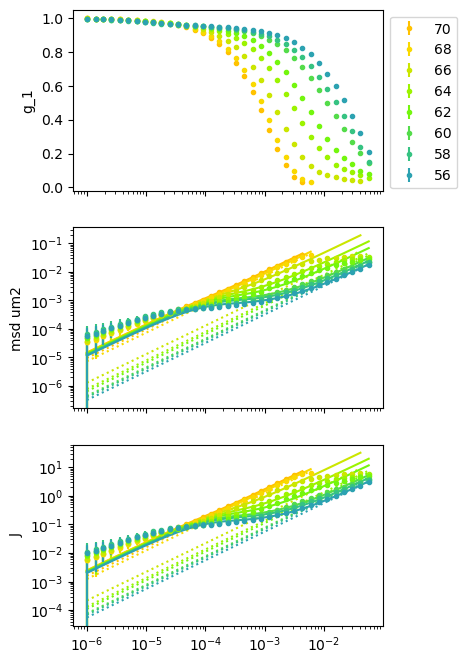

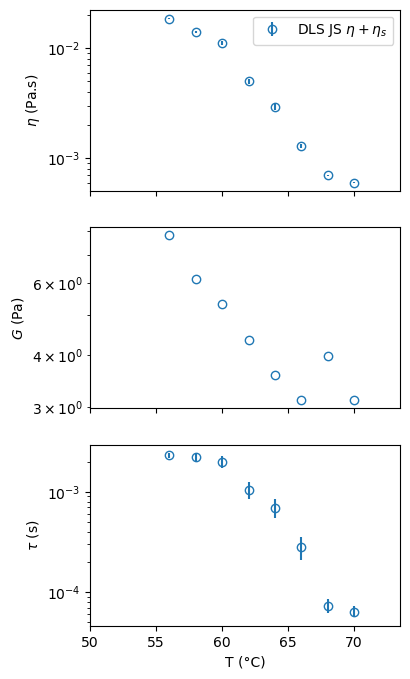

In [11]:
fig5, ax5 = plt.subplots(3, 1, figsize=(4,8), sharex=True)
fig4, ax4 = plt.subplots(3, 1, figsize=(4,8), sharex=True)
ax5[0].set_xscale('log')
ax5[1].set_yscale('log')
ax5[2].set_yscale('log')
ax5[0].set_ylabel('g_1')
ax5[1].set_ylabel('msd um2')
ax5[2].set_ylabel('J')

s = 0
sum_count = 0
paramsDLS = np.zeros((26,7))
k = uncertainties.ufloat(20,0)

for T in range(10,26,2):
    print(f'temperature {labels[T]} C')
    g1 = G1[T,:]
    msd = MSD[T,:]
    err_f = 1 - g1[0]
    err_msd_min = err_minus[T,:]
    err_msd_max = err_plus[T,:]
    # err_msd = (err_msd_min+err_msd_max)/2
    # print(err_msd_min - err_msd_max)
    select = np.where(g1>10*err_f)[0]
    ax5[0].errorbar(Dt[select], g1[select], yerr=err_f, 
                    color=gradient[T], marker='.', linestyle='None', label=labels[T])
    ax5[1].errorbar(Dt[select], 1e12*msd[select], yerr=(1e12*err_msd_min[select], 1e12*err_msd_max[select]), 
                    color=gradient[T], marker='.', linestyle='None', label=labels[T])
    # yerr=(err_minus[T,:], err_plus[T,:]),
    # Product of the diffusion coefficient and viscosity (independent of viscosity)
    D_eta_s = const.Boltzmann * const.convert_temperature(labels[T], 'C', 'K')/(6*π*a)   #SI unit
    J = -1/(q**2 * D_eta_s) * unumpy.log(unumpy.uarray(g1, err_f)) #SI unit
    ax5[2].errorbar(Dt[select], unumpy.nominal_values(J[select]), yerr=unumpy.std_devs(J[select]), 
                    color=gradient[T], marker='.', linestyle='None', label=labels[T])
    eta_s = ufloat(float(eta_w(labels[T])), 1e-7)   #SI unit Pa.s
    print(f'water viscosity = {eta_s:.2}')
    # fit newtonien
    popt, pcov = curve_fit(
        lambda t, eta: t / eta,
        Dt[select],
        unumpy.nominal_values(J[select]),
        p0 = eta_s.n
    )
    eta = ufloat(popt[0], pcov[0,0]) 
    print(f'fit newtonien: eta = {eta:.2e} Pa.s')
    ax5[1].plot(Dt[select], 6 * D_eta_s * Dt[select] / (eta.n * 1e-12), color=gradient[T], ls=':')
    ax5[2].plot(Dt[select], Dt[select] / eta.n, color=gradient[T], ls=':')
    # fit JS
    k = max(uncertainties.ufloat(20,0),k)
      
    popt, pcov = curve_fit(
            lambda t, k, eta: np.exp(-q**2 * D_eta_s * jsJ(t, k, eta, eta_s.n)),
            Dt[select],
            g1[select],
            p0 = [k.n, 0.015],
            bounds=[[0,0], [np.inf, np.inf]]
        )
    k, eta = uncertainties.correlated_values(popt, pcov)
    print(k, eta)
    ax5[1].plot(Dt[select], 6e12* D_eta_s * jsJ(Dt[select], k.n, eta.n, eta_s.n), color=gradient[T], ls='-')
    # if k.n<1 or k.n>1e5 or k.s>k.n/2:
    #     popt, pcov = curve_fit(
    #         lambda t, eta_s: np.log(6 * D_eta_s/eta_s * t),
    #         Dt[select],
    #         np.log(msd[select]),
    #         [eta_s.n]
    #     )
    #     eta = uncertainties.correlated_values(popt, pcov)[0] - eta_s
    #     k = uncertainties.ufloat(0,0)
    paramsDLS[T] = labels[T], k.n, eta.n, eta_s.n, k.s, max(0,eta.s-eta_s.s), eta_s.s
    print(f'fit JS: k = {k}, eta = {eta}')
    ax5[2].plot(Dt[select], jsJ(Dt[select], k.n, eta.n, eta_s.n), color=gradient[T], ls='-')

ax5[0].set_xscale('log')
ax5[1].set_yscale('log')
ax5[2].set_yscale('log')

ax5[0].legend(loc='upper left', bbox_to_anchor=(1, 1))

ax4[0].errorbar(
        paramsDLS[:,0], paramsDLS[:, 2]+paramsDLS[:, 3],
        paramsDLS[:, 5]+paramsDLS[:, 6],
        ls='none', marker='o', mfc='none',
        label=r'DLS JS $\eta+\eta_s$'
    )
ax4[1].errorbar(
        paramsDLS[:,0], paramsDLS[:, 1],
        ls='none', marker='o', mfc='none', label=r'DLS JS $k$'
    )
tau = unumpy.uarray(paramsDLS[:, 2], paramsDLS[:, 5])[paramsDLS[:, 1]>0] / unumpy.uarray(paramsDLS[:, 1], paramsDLS[:, 4])[paramsDLS[:, 1]>0]
ax4[2].errorbar(
        paramsDLS[paramsDLS[:, 1]>0,0],
        unumpy.nominal_values(tau),
        unumpy.std_devs(tau),
        ls='none', marker='o', mfc='none', label=r'DLS JS $\eta/k$'
    )

for ax in ax4:
    ax.set_yscale('log')
    # ax.axvline(Tmin, ls=':', color='k')
ax4[0].set_ylabel(r'$\eta$ (Pa.s)')
ax4[1].set_ylabel(r'$G$ (Pa)')
ax4[2].set_ylabel(r'$\tau$ (s)')
ax4[2].set_xlabel('T (°C)')
ax4[0].legend(loc='upper right')
ax4[0].set_xlim(50,)

70
0.00040350+/-0.00000010
0.69+/-0.18 0.000259+/-0.000013
[ 7.00000000e+01  0.00000000e+00 -4.03499419e-04  4.03500000e-04
  0.00000000e+00  1.46184030e-16  1.00000000e-07]
68
0.00041484+/-0.00000010
0.35+/-0.05 0.00062+/-0.00006
[ 6.80000000e+01  0.00000000e+00 -4.14843220e-04  4.14843896e-04
  0.00000000e+00  3.34005751e-16  1.00000000e-07]
66
0.00042674+/-0.00000010
0.270+/-0.018 0.0121+/-0.0019
[ 6.60000000e+01  0.00000000e+00 -4.26739586e-04  4.26740696e-04
  0.00000000e+00  9.19250949e-15  1.00000000e-07]
64
0.00043920+/-0.00000010
0.55+/-0.06 0.0117+/-0.0011
[ 6.40000000e+01  0.00000000e+00 -4.39200616e-04  4.39202907e-04
  0.00000000e+00  8.58571507e-14  1.00000000e-07]
62
0.00045227+/-0.00000010
1.04+/-0.14 0.0114+/-0.0008
[6.20000000e+01 1.03544384e+00 1.14098940e-02 4.52268318e-04
 1.41906875e-01 7.70016840e-04 1.00000000e-07]
60
0.00046600+/-0.00000010
2.9+/-0.4 0.0145+/-0.0005
[6.00000000e+01 2.85587409e+00 1.45027642e-02 4.66000000e-04
 4.02379389e-01 5.06781570e-04 1.00

C:\Users\ajiye\AppData\Local\Temp\ipykernel_54664\777029603.py:40: RuntimeWarning: divide by zero encountered in scalar divide
  return t/(η+ηs) + 1/k * (η/(η+ηs))**2 * (1 - np.exp(-k*(1/η + 1/ηs)*t))
C:\Users\ajiye\AppData\Local\Temp\ipykernel_54664\777029603.py:40: RuntimeWarning: invalid value encountered in multiply
  return t/(η+ηs) + 1/k * (η/(η+ηs))**2 * (1 - np.exp(-k*(1/η + 1/ηs)*t))


(50.0, 73.5)

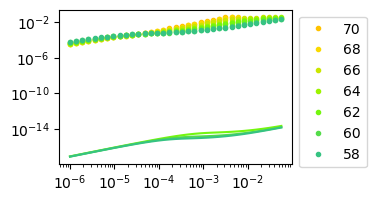

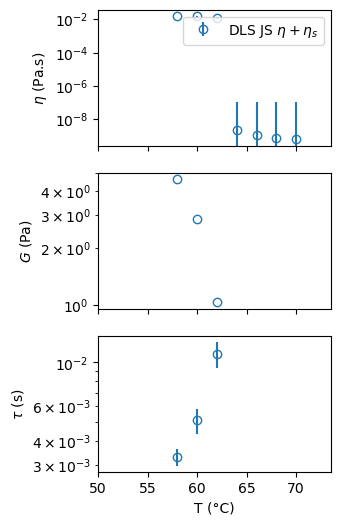

In [228]:
fig5, ax5 = plt.subplots(1, 1, figsize=(3,2), sharex=True)
fig4, ax4 = plt.subplots(3, 1, figsize=(3,6), sharex=True)
ax5.set_xscale('log')
ax5.set_yscale('log')

s = 0
sum_count = 0
paramsDLS = np.zeros((24,7))
k = uncertainties.ufloat(20,0)

for T in range(10,24,2):
    print(labels[T])
    g1 = G1[T,:]
    msd = MSD[T,:]
    err_f = 1 - g1[0]
    select = np.where(g1>10*err_f)[0]
    ax5.plot(Dt[select], msd[select], color=gradient[T], marker='.', linestyle='None', label=labels[T])

    # J = - 1 / (q*1e6)**2 
    
    # Product of the diffusion coefficient and viscosity (independent of viscosity)
    D_eta_s = const.Boltzmann * const.convert_temperature(labels[T], 'C', 'K')/(6*π*a)
    # fit JS
    k = max(uncertainties.ufloat(20,0),k)
    eta_s = ufloat(float(eta_w(labels[T])), 1e-7)
    # eta_s = eta_w(labels[T])
    print(eta_s)
    popt, pcov = curve_fit(
            lambda t, k, eta: jsJ(t, k, eta, eta_s.n),
            Dt[select],
            -1/(q*1e6)**2 / D_eta_s *np.log(g1[select]),
            p0 = [k.n, 0.015],
            bounds=[[0,0], [np.inf, np.inf]]
        )
    k, eta = uncertainties.correlated_values(popt, pcov)
    print(k, eta)
    if k.n<1 or k.n>1e5 or k.s>k.n/2:
        popt, pcov = curve_fit(
                lambda t, eta_s: np.exp(-(q*1e6)**2 * D_eta_s/eta_s * t),
                Dt[select]*1e-6,
                g1[select],
                [eta_s.n]
            )
        eta = uncertainties.correlated_values(popt, pcov)[0] - eta_s
        k = uncertainties.ufloat(0,0)
    paramsDLS[T] = labels[T], k.n, eta.n, eta_s.n, k.s, max(0,eta.s-eta_s.s), eta_s.s
    print(paramsDLS[T])
    ax5.plot(Dt[select], 4 *D_eta_s * jsJ(Dt[select], paramsDLS[T,1], paramsDLS[T,2], paramsDLS[T,3]), color=gradient[T], ls='-')

ax5.set_xscale('log')
ax5.set_yscale('log')
ax5.legend(loc='upper left', bbox_to_anchor=(1, 1))

ax4[0].errorbar(
        paramsDLS[:,0], paramsDLS[:, 2]+paramsDLS[:, 3],
        paramsDLS[:, 5]+paramsDLS[:, 6],
        ls='none', marker='o', mfc='none',
        label=r'DLS JS $\eta+\eta_s$'
    )
ax4[1].errorbar(
        paramsDLS[:,0], paramsDLS[:, 1],
        ls='none', marker='o', mfc='none', label=r'DLS JS $k$'
    )
tau = unumpy.uarray(paramsDLS[:, 2], paramsDLS[:, 5])[paramsDLS[:, 1]>0] / unumpy.uarray(paramsDLS[:, 1], paramsDLS[:, 4])[paramsDLS[:, 1]>0]
ax4[2].errorbar(
        paramsDLS[paramsDLS[:, 1]>0,0],
        unumpy.nominal_values(tau),
        unumpy.std_devs(tau),
        ls='none', marker='o', mfc='none', label=r'DLS JS $\eta/k$'
    )

for ax in ax4:
    ax.set_yscale('log')
    # ax.axvline(Tmin, ls=':', color='k')
ax4[0].set_ylabel(r'$\eta$ (Pa.s)')
ax4[1].set_ylabel(r'$G$ (Pa)')
ax4[2].set_ylabel(r'$\tau$ (s)')
ax4[2].set_xlabel('T (°C)')
ax4[0].legend(loc='upper right')
ax4[0].set_xlim(50,)

Raw data of cooling 1, MSD calculation and first & last values of g_1 for triage criteria

<>:28: SyntaxWarning: invalid escape sequence '\m'
<>:28: SyntaxWarning: invalid escape sequence '\m'
C:\Users\ajiye\AppData\Local\Temp\ipykernel_14960\1592689275.py:28: SyntaxWarning: invalid escape sequence '\m'
  ax1[1].set_ylabel('MSD $\mu m ^2$')


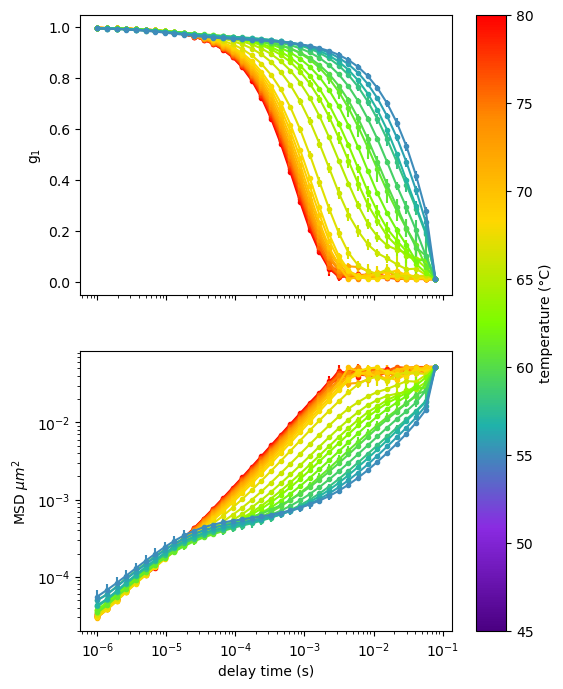

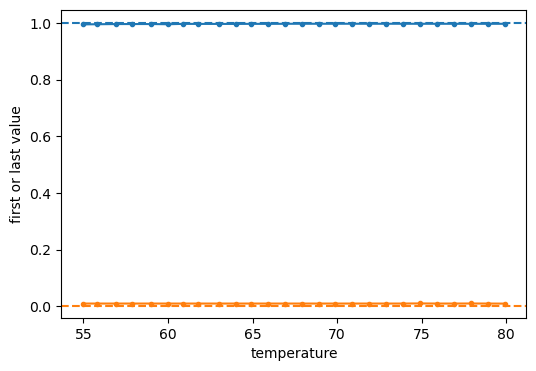

In [9]:
fig1, ax1 = plt.subplots(2, 1, figsize=(6,8), sharex=True)
fig2, ax2 = plt.subplots(1, 1, figsize=(6,4))

Tp = range(26)
first_v, last_v = [], []
for i in Tp:
    f1 = unumpy.uarray(np.mean(cool1[i,:,:], axis=0), np.std(cool1[i,:,:], axis=0))
    ax1[0].errorbar(Dt, unumpy.nominal_values(f1), yerr=unumpy.std_devs(f1), 
                    color=gradient[i], alpha=1, linestyle='-', marker='.', label=1)
    first_v.append(f1[0])
    last_v.append(f1[-1])
    msd1 = f2msd(f1, q)
    ax1[1].errorbar(Dt, unumpy.nominal_values(msd1), yerr=unumpy.std_devs(msd1), 
                    color=gradient[i], alpha=1, linestyle='-', marker='.', label=1)

ax2.errorbar(T1[:len(Tp),0], unumpy.nominal_values(first_v),
             xerr=np.std(T1[:len(Tp),:], axis=1), yerr=unumpy.std_devs(first_v),
             color='tab:blue', alpha=1, marker='.', label=1)
ax2.errorbar(T1[:len(Tp),0], unumpy.nominal_values(last_v), 
             xerr=np.std(T1[:len(Tp),:], axis=1), yerr=unumpy.std_devs(last_v),
             color='tab:orange', alpha=1, marker='.')
ax2.axhline(1, color='tab:blue', linestyle='--')
ax2.axhline(0, color='tab:orange', linestyle='--')
ax1[0].set_xscale('log')
ax1[1].set_yscale('log')
ax1[1].set_xlabel('delay time (s)')
ax1[0].set_ylabel('g$_1$')
ax1[1].set_ylabel('MSD $\mu m ^2$')
ax2.set_ylabel('first or last value')
ax2.set_xlabel('temperature')
# ax2.legend()
norm = Normalize(vmin=45, vmax=80)
fig1.colorbar(plt.cm.ScalarMappable(norm=norm,cmap=cmap), ax=ax1, label='temperature (°C)')


# Loading Y16SE0 data, and water viscosity data

In [12]:
dataNOSE = {}
for gel in range(1,71):
    fname = f'C:/Users/ajiye/Documents/DLS/2023-01-19/motif high temp/autocorr-gel6_{gel:02d}.csv'
    with codecs.open(fname, 'r', encoding='shift_jis') as f:
        for line in f:
            if 'Temperature of the Holder' in line:
                T = float(line.split(',')[1])
    dataNOSE[T] = np.loadtxt(fname, skiprows=41, encoding = 'shift_jis', delimiter=',')

In [13]:
TNOSE = np.array([T for T, data in dataNOSE.items() if np.argmax(data[:,1])==0])
normNOSE = max([data[0,1] for T, data in dataNOSE.items() if np.argmax(data[:,1])==0])

# Extraction of mechanical properties

In [ ]:
paramsDLS = np.zeros((len(goodT), 4))
k=20
for i, T in enumerate(goodT):
    data = dataDLS[T]
    good = (dataDLS[T][:,1]>1e-4)
    
    bestT = TNOSE[np.argmin(np.abs(TNOSE-T))]
    data2 = dataNOSE[bestT]
    good2 = (data2[:,1]>0.2)
    a = 0.250e-6
    D_eta_s = const.Boltzmann * const.convert_temperature(T, 'C', 'K')/(6*π*a)

    eta_s, = curve_fit(
        lambda t, eta_s: np.exp(-(q*1e6)**2 * D_eta_s/eta_s * t),
        data2[good2,0]*1e-6,
        data2[good2,1],
        [eta_w(T)]
    )[0]
    if good.sum()< 14:
        break
    #fit Maxwell decay on medium to long times of the data with SE
    etaM, A = curve_fit(
        lambda t, eta, A: A * np.exp(-(q*1e6)**2 * D_eta_s/eta *t),
        data[good][12:,0]*1e-6,
        data[good][12:,1],
        [1e-2, 0.9],
    )[0]
    if etaM <eta_s:
        eta = 0
        eta_s = min(etaM, eta_s)
        k=0
    else:
        k, eta = curve_fit(
            lambda t, k, eta: np.exp(-(q*1e6)**2 * D_eta_s * jsJ(t, k, eta, eta_s)),
            data[good,0]*1e-6,
            data[good,1],
            [200, etaM]
        )[0]
    paramsDLS[i] = T, k, eta, eta_s